## Analysis
### 1. Stock numbers forecasting using ARIMA (AutoRegressive Integrated Moving Average)
Utilizing ARIMA, an established time series analysis method, can provide insightful predictions. By examining historical stock data, ARIMA models can identify patterns and trends,
### 2. Product popularity in Coquitlam based on it frequencies being replenished
Analyzing product popularity in Coquitlam based on replenishment frequencies offers valuable insights. By tracking how often products need replenishment, we can gather information about customer demand and preferences
### 3. Impact of discount on stock level
Exploring the impact of discounts on stock levels provides valuable insights into consumer behavior and purchasing patterns. We want to analyize if the discounted products has a significant difference in term of stock level change compared to not discounted products

### Import Libraries

In [1]:
#import libraries
import pandas as pd
import glob
from datetime import datetime
from io import StringIO
import boto3
import s3fs
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression

### - Retrieve Weekly Artificial Plants CSV Files from S3 Bucket

In [2]:
#S3 path details
bucket_name = 'csis4495'
folder_name = 'weekly_artificial_plants'
file_pattern = 'weekly_products_artificial_plants_'

# Initialize s3fs filesystem object
fs = s3fs.S3FileSystem(anon=False)  # Use anon=False if your S3 bucket is private

# List all files in the specified folder
path = f'{bucket_name}/{folder_name}'  # Adjusted to include the folder name
files = fs.ls(path)

# Filter files by your pattern
csv_files = [f for f in files if file_pattern in f]

# Read and concatenate all matching CSV files into a single DataFrame
df_list = []
for file in csv_files:
    with fs.open(f'{file}') as f:
        df_list.append(pd.read_csv(f, encoding='ISO-8859-1'))

df = pd.concat(df_list, ignore_index=True)


# Add a new column with 'artificial' as its value for every row
df['product_type'] = 'artificial'

# Summing stock numbers for British Columbia (BC)
df['stock_number_BC'] = df['stock_number_coquitlam'] + df['stock_number_richmond']

# Summing stock numbers for Quebec (QC)
df['stock_number_QC'] = df['stock_number_quebec'] + df['stock_number_boucherville'] + df['stock_number_montreal']

# Stock number for Nova Scotia (NS) is just from Halifax
df['stock_number_NS'] = df['stock_number_halifax']

# Summing stock numbers for Ontario (ON)
df['stock_number_ON'] = df['stock_number_ottawa'] + df['stock_number_nyork'] + df['stock_number_etobicoke'] + df['stock_number_vaughan'] + df['stock_number_burlington']

# Stock number for Manitoba (MB) is just from Winnipeg
df['stock_number_MB'] = df['stock_number_winnipeg']

# Summing stock numbers for Alberta (AB)
df['stock_number_AB'] = df['stock_number_edmonton'] + df['stock_number_calgary']

# Display the shape and first few rows of the concatenated DataFrame
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4021 entries, 0 to 4020
Data columns (total 43 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   current_date                    4021 non-null   object
 1   image_url                       4021 non-null   object
 2   product_name                    4021 non-null   object
 3   product_link                    4021 non-null   object
 4   product_size                    3814 non-null   object
 5   product_sku                     4021 non-null   int64 
 6   product_price_old               4021 non-null   object
 7   product_price_new               95 non-null     object
 8   stock_probability_coquitlam     3994 non-null   object
 9   stock_number_coquitlam          4021 non-null   int64 
 10  stock_probability_richmond      3974 non-null   object
 11  stock_number_richmond           4021 non-null   int64 
 12  stock_probability_halifax       4021 non-null   

In [3]:
df

,current_date,image_url,product_name,product_link,product_size,product_sku,product_price_old,product_price_new,stock_probability_coquitlam,stock_number_coquitlam,...,stock_number_edmonton,stock_probability_calgary,stock_number_calgary,product_type,stock_number_BC,stock_number_QC,stock_number_NS,stock_number_ON,stock_number_MB,stock_number_AB
0,2024-02-05,https://www.ikea.com/ca/en/images/products/fej...,"FEJKA, Artificial potted plant",https://www.ikea.com/ca/en/p/fejka-artificial-...,"23 cm (9 "")",10467804,$69.99,NaN,HIGH_IN_STOCK,12,...,15,HIGH_IN_STOCK,21,artificial,25,53,24,59,14,36
1,2024-02-05,https://www.ikea.com/ca/en/images/products/fej...,"FEJKA, Artificial plant with wall holder",https://www.ikea.com/ca/en/p/fejka-artificial-...,NaN,30548625,$6.99,NaN,HIGH_IN_STOCK,86,...,54,HIGH_IN_STOCK,76,artificial,223,112,45,401,90,130
2,2024-02-05,https://www.ikea.com/ca/en/images/products/fej...,"FEJKA, Artificial potted plant",https://www.ikea.com/ca/en/p/fejka-artificial-...,"21 cm (8 ¼ "")",70491575,$79.99,NaN,HIGH_IN_STOCK,6,...,17,HIGH_IN_STOCK,21,artificial,21,69,11,87,12,38
3,2024-02-05,https://www.ikea.com/ca/en/images/products/fej...,"FEJKA, Artificial potted plant",https://www.ikea.com/ca/en/p/fejka-artificial-...,"9 cm (3 ½ "")",40349531,$9.99,NaN,HIGH_IN_STOCK,97,...,200,HIGH_IN_STOCK,139,artificial,137,585,400,1733,340,339
4,2024-02-05,https://www.ikea.com/ca/en/images/products/fej...,"FEJKA, Artificial potted plant",https://www.ikea.com/ca/en/p/fejka-artificial-...,"23 cm (9 "")",80548185,$99,NaN,OUT_OF_STOCK,0,...,18,HIGH_IN_STOCK,12,artificial,5,35,12,80,17,30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4016,2024-03-17,https://www.ikea.com/ca/en/images/products/fej...,"FEJKA, Artificial plant with wall holder",https://www.ikea.com/ca/en/p/fejka-artificial-...,NaN,70548628,$6.99,NaN,HIGH_IN_STOCK,100,...,2,HIGH_IN_STOCK,96,artificial,161,182,12,465,26,98
4017,2024-03-17,https://www.ikea.com/ca/en/images/products/fej...,"FEJKA, Artificial potted plant",https://www.ikea.com/ca/en/p/fejka-artificial-...,"19 cm (7 ½ "")",40395288,$59.99,NaN,NaN,38,...,12,HIGH_IN_STOCK,23,artificial,67,137,9,134,15,35
4018,2024-03-17,https://www.ikea.com/ca/en/images/products/fej...,"FEJKA, Artificial potted plant",https://www.ikea.com/ca/en/p/fejka-artificial-...,"9 cm (3 ½ "")",20433936,$9.99,NaN,NaN,11,...,92,HIGH_IN_STOCK,24,artificial,16,529,38,472,38,116
4019,2024-03-17,https://www.ikea.com/ca/en/images/products/fej...,"FEJKA, Artificial potted plant",https://www.ikea.com/ca/en/p/fejka-artificial-...,"17 cm (6 ¾ "")",70186660,$49.99,NaN,HIGH_IN_STOCK,17,...,10,HIGH_IN_STOCK,7,artificial,34,110,7,113,16,17


### -Retrieve Weekly Real Plants CSV Files from S3 Bucket

In [4]:
bucket_name = 'csis4495'
folder_name = 'weekly_real_plants'
file_pattern = 'weekly_products_real_plants_'

# Initialize s3fs filesystem object
fs = s3fs.S3FileSystem(anon=False)  # Use anon=False if your S3 bucket is private

# List all files in the specified folder
path = f'{bucket_name}/{folder_name}'  # Adjusted to include the folder name
files = fs.ls(path)

# Filter files by your pattern
csv_files = [f for f in files if file_pattern in f]

# Read and concatenate all matching CSV files into a single DataFrame
df_list = []
for file in csv_files:
    with fs.open(f'{file}') as f:
        df_list.append(pd.read_csv(f, encoding='ISO-8859-1'))

df2 = pd.concat(df_list, ignore_index=True)



# Add a new column with 'artificial' as its value for every row
df2['product_type'] = 'real'

# Sum stock numbers for British Columbia (BC)
df2['stock_number_BC'] = df2['stock_number_coquitlam'] + df2['stock_number_richmond']

# Sum stock numbers for Quebec (QC)
df2['stock_number_QC'] = df2['stock_number_quebec'] + df2['stock_number_boucherville'] + df2['stock_number_montreal']

# Sum number for Nova Scotia (NS) is just from Halifax
df2['stock_number_NS'] = df2['stock_number_halifax']

# Summing stock numbers for Ontario (ON)
df2['stock_number_ON'] = df2['stock_number_ottawa'] + df2['stock_number_nyork'] + df2['stock_number_etobicoke'] + df2['stock_number_vaughan'] + df2['stock_number_burlington'] +  df2['stock_number_burlington'] 

# Stock number for Manitoba (MB) is just from Winnipeg
df2['stock_number_MB'] = df2['stock_number_winnipeg']

# Sum stock numbers for Alberta (AB)
df2['stock_number_AB'] = df2['stock_number_edmonton'] + df2['stock_number_calgary']

# Display the shape and first few rows of the concatenated DataFrame
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5459 entries, 0 to 5458
Data columns (total 45 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   current_date                    5459 non-null   object
 1   image_url                       5459 non-null   object
 2   product_name                    5459 non-null   object
 3   product_link                    5459 non-null   object
 4   product_size                    5159 non-null   object
 5   product_sku                     5459 non-null   int64 
 6   product_price_old               5459 non-null   object
 7   product_price_new               82 non-null     object
 8   stock_probability_coquitlam     5419 non-null   object
 9   stock_number_coquitlam          5459 non-null   int64 
 10  stock_probability_richmond      5394 non-null   object
 11  stock_number_richmond           5459 non-null   int64 
 12  stock_probability_halifax       5459 non-null   

In [5]:
df_real = df2[
    df2['product_name'].str.contains('potted plant', case=False) &
    ~df2['product_name'].str.contains('artificial', case=False) &
    ~df2['product_name'].str.contains('Artifi', case=False)
]

df_real['current_date'] = pd.to_datetime(df_real['current_date'], infer_datetime_format=True, errors='coerce')
# Display the shape and first few rows of the filtered DataFrame
df_real.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1434 entries, 0 to 5410
Data columns (total 45 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   current_date                    1229 non-null   datetime64[ns]
 1   image_url                       1434 non-null   object        
 2   product_name                    1434 non-null   object        
 3   product_link                    1434 non-null   object        
 4   product_size                    1434 non-null   object        
 5   product_sku                     1434 non-null   int64         
 6   product_price_old               1434 non-null   object        
 7   product_price_new               0 non-null      object        
 8   stock_probability_coquitlam     1425 non-null   object        
 9   stock_number_coquitlam          1434 non-null   int64         
 10  stock_probability_richmond      1419 non-null   object        
 11  stock_num

C:\Users\arifi\AppData\Local\Temp\ipykernel_9396\1119616331.py:7: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df_real['current_date'] = pd.to_datetime(df_real['current_date'], infer_datetime_format=True, errors='coerce')
C:\Users\arifi\AppData\Local\Temp\ipykernel_9396\1119616331.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_real['current_date'] = pd.to_datetime(df_real['current_date'], infer_datetime_format=True, errors='coerce')


In [6]:
df_real

,current_date,image_url,product_name,product_link,product_size,product_sku,product_price_old,product_price_new,stock_probability_coquitlam,stock_number_coquitlam,...,stock_number_edmonton,stock_probability_calgary,stock_number_calgary,product_type,stock_number_BC,stock_number_QC,stock_number_NS,stock_number_ON,stock_number_MB,stock_number_AB
0,2024-02-05,https://www.ikea.com/ca/en/images/products/him...,"HIMALAYAMIX, Potted plant",https://www.ikea.com/ca/en/p/himalayamix-potte...,"10 cm (4 "")",20197227,$4.99,NaN,OUT_OF_STOCK,0,...,12,MEDIUM_IN_STOCK,4,real,17,232,108,812,96,16
1,2024-02-05,https://www.ikea.com/ca/en/images/products/san...,"SANSEVIERIA TRIFASCIATA, Potted plant",https://www.ikea.com/ca/en/p/sansevieria-trifa...,"15 cm (6 "")",90296969,$9.99,NaN,HIGH_IN_STOCK,23,...,2,HIGH_IN_STOCK,50,real,24,84,36,152,28,52
2,2024-02-05,https://www.ikea.com/ca/en/images/products/tro...,"TROPISK, Potted plant",https://www.ikea.com/ca/en/p/tropisk-potted-pl...,"30.5 cm (12 "")",70219137,$64.99,NaN,HIGH_IN_STOCK,15,...,2,HIGH_IN_STOCK,50,real,22,13,3,147,28,52
3,2024-02-05,https://www.ikea.com/ca/en/images/products/dra...,"DRACAENA MARGINATA, Potted plant",https://www.ikea.com/ca/en/p/dracaena-marginat...,"20.5 cm (8 "")",80303531,$22.99,NaN,HIGH_IN_STOCK,34,...,33,HIGH_IN_STOCK,22,real,39,94,14,92,23,55
4,2024-02-05,https://www.ikea.com/ca/en/images/products/pac...,"PACHIRA AQUATICA, Potted plant",https://www.ikea.com/ca/en/p/pachira-aquatica-...,"13 cm (5 "")",40399173,$12.99,NaN,HIGH_IN_STOCK,19,...,58,HIGH_IN_STOCK,43,real,34,97,20,102,40,101
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5365,2024-03-17,https://www.ikea.com/ca/en/images/products/sai...,"SAINTPAULIA, Potted plant",https://www.ikea.com/ca/en/p/saintpaulia-potte...,"10 cm (4 "")",20569996,$5.99,NaN,HIGH_IN_STOCK,8,...,0,LOW_IN_STOCK,1,real,19,12,16,99,7,1
5407,2024-03-17,https://www.ikea.com/ca/en/images/products/aec...,"AECHMEA, Potted plant",https://www.ikea.com/ca/en/p/aechmea-potted-pl...,"15 cm (6 "")",569997,$22.99,NaN,OUT_OF_STOCK,0,...,282,HIGH_IN_STOCK,250,real,0,0,0,2294,915,532
5408,2024-03-17,https://www.ikea.com/ca/en/images/products/kal...,"KALANCHOE, Potted plant",https://www.ikea.com/ca/en/p/kalanchoe-potted-...,"11.5 cm (4 ½ "")",40282757,$5.99,NaN,HIGH_IN_STOCK,60,...,23,HIGH_IN_STOCK,60,real,90,0,11,16,35,83
5409,2024-03-17,https://www.ikea.com/ca/en/images/products/hed...,"HEDERA HELIX, Potted plant",https://www.ikea.com/ca/en/p/hedera-helix-pott...,"13 cm (5 "")",10570194,$8.99,NaN,HIGH_IN_STOCK,9,...,23,HIGH_IN_STOCK,60,real,21,3,7,16,35,83


In [7]:
df_combined = pd.concat([df, df_real], ignore_index=True)
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5455 entries, 0 to 5454
Data columns (total 45 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   current_date                    5250 non-null   object 
 1   image_url                       5455 non-null   object 
 2   product_name                    5455 non-null   object 
 3   product_link                    5455 non-null   object 
 4   product_size                    5248 non-null   object 
 5   product_sku                     5455 non-null   int64  
 6   product_price_old               5455 non-null   object 
 7   product_price_new               95 non-null     object 
 8   stock_probability_coquitlam     5419 non-null   object 
 9   stock_number_coquitlam          5455 non-null   int64  
 10  stock_probability_richmond      5393 non-null   object 
 11  stock_number_richmond           5455 non-null   int64  
 12  stock_probability_halifax       54

In [8]:
# Assuming df_combined is your combined DataFrame
duplicate_rows = df_combined.duplicated()

# To see if there are any duplicate rows
has_duplicates = duplicate_rows.any()
print("Are there any duplicate rows?", has_duplicates)

# To count the number of duplicate rows
number_of_duplicates = duplicate_rows.sum()
print("Number of duplicate rows:", number_of_duplicates)


Are there any duplicate rows? True
Number of duplicate rows: 41


In [9]:
# Assuming df_combined is your combined DataFrame
# Remove duplicate rows and keep the first occurrence of each duplicate
df_combined = df_combined.drop_duplicates()

# If you want to keep the last occurrence of each duplicate instead
df_combined = df_combined.drop_duplicates(keep='last')

duplicate_rows = df_combined.duplicated()

has_duplicates = duplicate_rows.any()
print("Are there any duplicate rows?", has_duplicates)

# To count the number of duplicate rows
number_of_duplicates = duplicate_rows.sum()
print("Number of duplicate rows:", number_of_duplicates)

Are there any duplicate rows? False
Number of duplicate rows: 0


## 1. Stock numbers forecasting using ARIMA (AutoRegressive Integrated Moving Average)
## https://machinelearningmastery.com/arima-for-time-series-forecasting-with-python/

In [10]:
df['current_date'] = pd.to_datetime(df['current_date'], infer_datetime_format=True, errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4021 entries, 0 to 4020
Data columns (total 43 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   current_date                    4021 non-null   datetime64[ns]
 1   image_url                       4021 non-null   object        
 2   product_name                    4021 non-null   object        
 3   product_link                    4021 non-null   object        
 4   product_size                    3814 non-null   object        
 5   product_sku                     4021 non-null   int64         
 6   product_price_old               4021 non-null   object        
 7   product_price_new               95 non-null     object        
 8   stock_probability_coquitlam     3994 non-null   object        
 9   stock_number_coquitlam          4021 non-null   int64         
 10  stock_probability_richmond      3974 non-null   object        
 11  stoc

C:\Users\arifi\AppData\Local\Temp\ipykernel_9396\2103816815.py:1: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df['current_date'] = pd.to_datetime(df['current_date'], infer_datetime_format=True, errors='coerce')


In [11]:
# Filter for product_sku 10467804 for video presentation
df_sku = df[df['product_sku'] == 10467804]
df_sku = df_sku.dropna(subset=['current_date'])

# Select only the current_date and stock_number_coquitlam columns
df_sku_coquitlam = df_sku[['product_sku','product_name','current_date', 'stock_number_coquitlam']]
# Display the DataFrame
df_sku_coquitlam

,product_sku,product_name,current_date,stock_number_coquitlam
0,10467804,"FEJKA, Artificial potted plant",2024-02-05,12
92,10467804,"FEJKA, Artificial potted plant",2024-02-06,12
184,10467804,"FEJKA, Artificial potted plant",2024-02-07,9
276,10467804,"FEJKA, Artificial potted plant",2024-02-08,6
368,10467804,"FEJKA, Artificial potted plant",2024-02-09,27
460,10467804,"FEJKA, Artificial potted plant",2024-02-10,26
552,10467804,"FEJKA, Artificial potted plant",2024-02-11,26
644,10467804,"FEJKA, Artificial potted plant",2024-02-12,23
736,10467804,"FEJKA, Artificial potted plant",2024-02-13,22
828,10467804,"FEJKA, Artificial potted plant",2024-02-14,21


In [12]:
# # Convert current_date to datetime format and set as index
df_sku_coquitlam['current_date'] = pd.to_datetime(df_sku_coquitlam['current_date'])
df_sku_coquitlam.set_index('current_date', inplace=True)


df_sku_coquitlam.sort_values('current_date', inplace=True)

from statsmodels.tsa.arima.model import ARIMA

# Selecting the stock number series
stock_series = df_sku_coquitlam['stock_number_coquitlam']

# Assuming an ARIMA(1,1,1) model for demonstration
model = ARIMA(stock_series, order=(1, 1, 1))
model_fit = model.fit()

# Summary of the model
print(model_fit.summary())

# Forecasting the next 7 time periods
forecast = model_fit.forecast(steps=7)

# Print the forecast
print(forecast)

                                 SARIMAX Results                                  
Dep. Variable:     stock_number_coquitlam   No. Observations:                   42
Model:                     ARIMA(1, 1, 1)   Log Likelihood                -134.945
Date:                    Mon, 25 Mar 2024   AIC                            275.890
Time:                            15:50:31   BIC                            281.031
Sample:                        02-05-2024   HQIC                           277.762
                             - 03-17-2024                                         
Covariance Type:                      opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6724      1.037      0.648      0.517      -1.360       2.705
ma.L1         -0.8262      0.620     -1.332      0.183      -2.042       0.390
sigma2        42.169

C:\Users\arifi\AppData\Local\Temp\ipykernel_9396\923792334.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sku_coquitlam['current_date'] = pd.to_datetime(df_sku_coquitlam['current_date'])
C:\Users\arifi\AppData\Local\Temp\ipykernel_9396\923792334.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sku_coquitlam.sort_values('current_date', inplace=True)
C:\Users\arifi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)

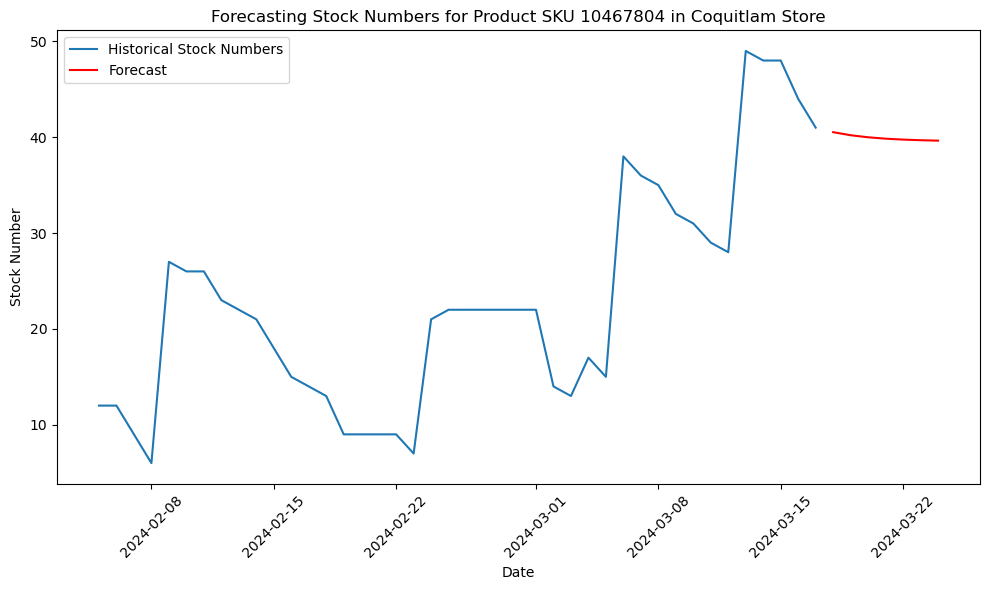

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(stock_series.index, stock_series, label='Historical Stock Numbers')

# Corrected forecast_index generation without 'closed' argument
forecast_index = pd.date_range(start=stock_series.index[-1], periods=8)[1:]  # Start from the next day after the last observation

plt.plot(forecast_index, forecast, label='Forecast', color='red')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Stock Number')
plt.title('Forecasting Stock Numbers for Product SKU 10467804 in Coquitlam Store')
plt.xticks(rotation=45)  # Rotate the x-axis labels for better readability
plt.tight_layout()  # Adjust layout
plt.show()



## 2. Product popularity in Coquitlam based on it frequencies being replenished

In [14]:
df_popular = df_combined.copy()
# Select the column for stock change calculations
stock_column = 'stock_number_coquitlam'  # Example stock column for one store

# Calculate the difference in stock level from one record to the next for each product
df_popular['stock_change'] = df_popular.groupby('product_sku')[stock_column].diff()

# A positive stock change indicates a restocking event
df_popular['is_restocked'] = df_popular['stock_change'] > 0

# Count restocking events for each product
restock_counts = df_popular.groupby('product_sku')['is_restocked'].sum().reset_index()

# Merge to get product names and sizes without changing the original df
restock_counts_with_names = restock_counts.merge(
    df_popular[['product_sku', 'product_name', 'product_size','product_type']].drop_duplicates(), 
    on='product_sku', 
    how='left'
)

# Sort products by restocking frequency in descending order
restock_counts_sorted = restock_counts_with_names.sort_values(by='is_restocked', ascending=False)

# Select the top 10 products based on restocking frequency
top_10_replenished_products = restock_counts_sorted.head(10)[['product_sku', 'product_name', 'product_size','product_type', 'is_restocked']]

top_10_replenished_products

,product_sku,product_name,product_size,product_type,is_restocked
11,409739,"SMYCKA, Artificial flower","130 cm (51 ¼ "")",artificial,13
88,50571672,"FEJKA, Artificial potted plant","15 cm (6 "")",artificial,11
22,571679,"FEJKA, Artificial potted plant","12 cm (4 ¾ "")",artificial,11
107,70466811,"FEJKA, Artificial potted plant","9 cm (3 ½ "")",artificial,10
138,90571670,"FEJKA, Artifi potted plant w pot, set of 3","6 cm (2 ¼ "")",artificial,10
56,30433945,"FEJKA, Artificial potted plant","9 cm (3 ½ "")",artificial,10
35,10570194,"HEDERA HELIX, Potted plant","13 cm (5 "")",real,10
39,20333588,"SMYCKA, Artificial flower","30 cm (11 ¾ "")",artificial,9
110,70548628,"FEJKA, Artificial plant with wall holder",NaN,artificial,9
89,50571691,"FEJKA, Artificial potted plant","12 cm (4 ¾ "")",artificial,8


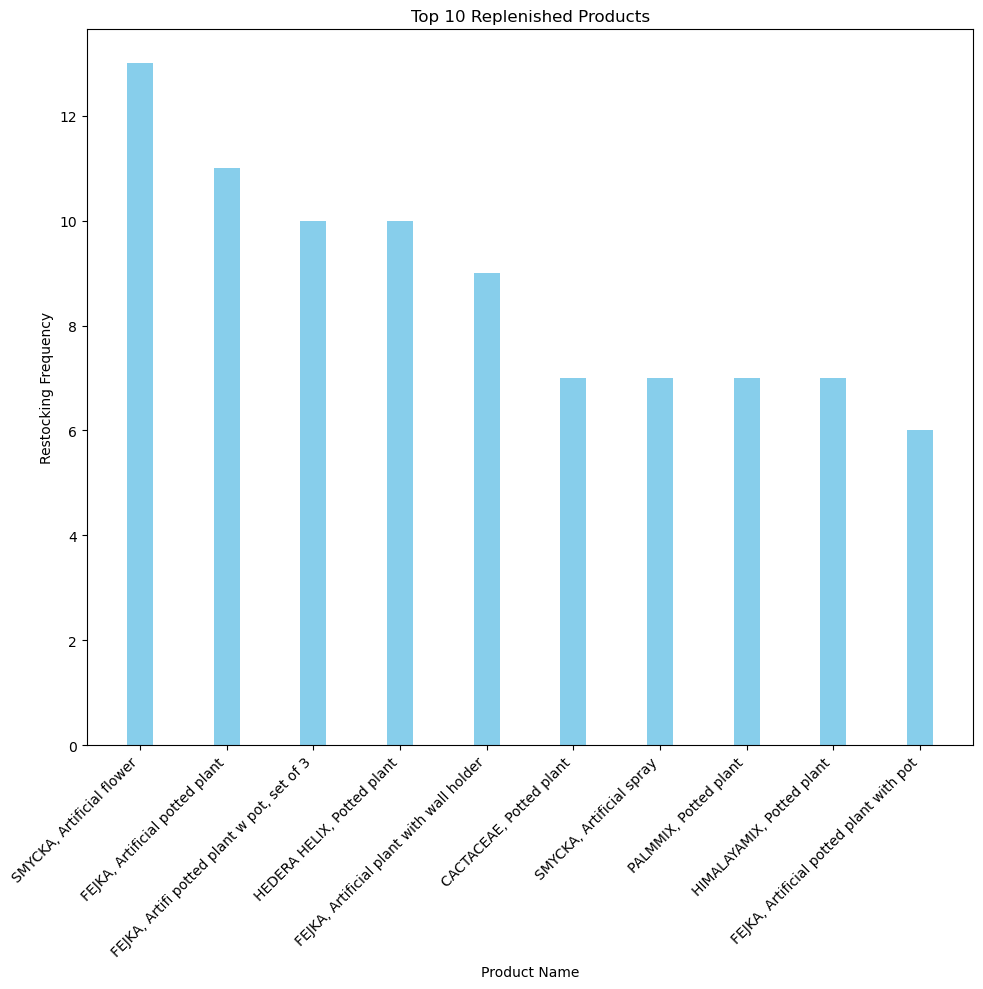

In [39]:
# Select the top 10 replenished products
top_10_products = restock_counts_sorted.head(22)

# Plotting the bar chart with smaller bars
plt.figure(figsize=(10, 10))  # Adjust the figure size as needed
plt.bar(top_10_products['product_name'], top_10_products['is_restocked'], color='skyblue', width=0.3)  # Adjust the width parameter to make bars smaller
plt.xlabel('Product Name')
plt.ylabel('Restocking Frequency')
plt.title('Top 10 Replenished Products')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Analysis :
In our analysis of restocking frequencies for the top 10 products in the Coquitlam store, we observed that artificial plants significantly dominate the restocking trends. Among the top 10 products, only one real plant product appeared(#5), while the remaining nine were artificial plants. This pattern suggests a notable preference for artificial plants among customers, especially notable during periods of cold and rainy weather conditions. The consistent demand for artificial plants underscores their popularity and highlights a potential consumer preference for low-maintenance, durable alternatives to real plants during this time.

## 3. Impact of discount on stock level

In [16]:
# # Assuming df is your DataFrame
# # Convert price columns to numeric
# df['product_price_old'] = pd.to_numeric(df['product_price_old'].astype(str).str.replace('$', ''), errors='coerce')
# df['product_price_new'] = pd.to_numeric(df['product_price_new'].astype(str).str.replace('$', ''), errors='coerce')

# # Calculate discount percentage
# df['discount_percentage'] = (df['product_price_old'] - df['product_price_new']) / df['product_price_old'] * 100

# # Identify products with discounts
# discounted_products = df[df['discount_percentage'] > 0]

# # Group by product SKU and calculate total stock change
# total_stock_change = df.groupby('product_sku')['stock_number_coquitlam'].diff().fillna(0)

# # Add total stock change to the DataFrame
# df['total_stock_change'] = total_stock_change

# # Calculate sample sizes for products with discounts and without discounts
# sample_size_discounted = len(discounted_products)
# sample_size_non_discounted = len(df) - sample_size_discounted

# # Calculate average stock change for products with discounts
# average_stock_change_discounted = df[df['discount_percentage'] > 0].groupby('current_date')['total_stock_change'].mean()
# average_stock_change_discounted_total = average_stock_change_discounted.mean() if not average_stock_change_discounted.empty else 0

# # Calculate average stock change for products without discounts
# average_stock_change_non_discounted = df[df['discount_percentage'] <= 0].groupby('current_date')['total_stock_change'].mean()
# average_stock_change_non_discounted_total = average_stock_change_non_discounted.mean() if not average_stock_change_non_discounted.empty else 0
# # Print discount percentage
# average_discount_percentage = df['discount_percentage'].mean()
# print("Average discount percentage: {:.2f}%".format(average_discount_percentage))

# # Print the sample sizes
# print("Sample size for products with discounts:", sample_size_discounted)
# print("Sample size for products without discounts:", sample_size_non_discounted)

# # Print the overall averages
# print("Average stock change for products with discounts:", average_stock_change_discounted_total)
# print("Average stock change for products without discounts:", average_stock_change_non_discounted_total)




In [17]:
import pandas as pd

# Create a new DataFrame for analysis
df_analysis = df.copy()

# Convert price columns to numeric
df_analysis['product_price_old'] = pd.to_numeric(df_analysis['product_price_old'].str.replace('$', ''), errors='coerce')
df_analysis['product_price_new'] = pd.to_numeric(df_analysis['product_price_new'].str.replace('$', ''), errors='coerce')

# Calculate discount percentage and identify discounted products
df_analysis['discount_percentage'] = (df_analysis['product_price_old'] - df_analysis['product_price_new']) / df_analysis['product_price_old'] * 100
df_analysis['has_discount'] = df_analysis['discount_percentage'] > 0

# Calculate daily stock change
df_analysis.sort_values(by=['product_sku', 'current_date'], inplace=True)
df_analysis['daily_stock_change_coquitlam'] = df_analysis.groupby('product_sku')['stock_number_coquitlam'].diff().fillna(0)

# Since sales are indicated by a decrease in stock, consider only negative changes
df_analysis['daily_sales_coquitlam'] = df_analysis['daily_stock_change_coquitlam'].apply(lambda x: -x if x < 0 else 0)

# Filter for sales data
df_sales = df_analysis[df_analysis['daily_sales_coquitlam'] > 0]

# Calculate average daily sales for discounted and non-discounted products
average_sales_discounted = df_sales[df_sales['has_discount']]['daily_sales_coquitlam'].mean()
average_sales_non_discounted = df_sales[~df_sales['has_discount']]['daily_sales_coquitlam'].mean()

# Calculate the average discount percentage for discounted products
average_discount_percentage = df_sales[df_sales['has_discount']]['discount_percentage'].mean()

# Count the number of samples for discounted and non-discounted products
sample_count_discounted = df_sales[df_sales['has_discount']].shape[0]
sample_count_non_discounted = df_sales[~df_sales['has_discount']].shape[0]

# Output the results
print(f"Average discount percentage for discounted products: {average_discount_percentage:.2f}%")
print(f"Sample size for discounted products: {sample_count_discounted}")
print(f"Sample size for non-discounted products: {sample_count_non_discounted}")
print(f"Average daily sales for discounted products: {average_sales_discounted}")
print(f"Average daily sales for non-discounted products: {average_sales_non_discounted}")


Average discount percentage for discounted products: 18.75%
Sample size for discounted products: 65
Sample size for non-discounted products: 1922
Average daily sales for discounted products: 25.846153846153847
Average daily sales for non-discounted products: 7.7804370447450575


### One of the sample sizes is 95 (for products with discounts) and the other is 3926 (for products without discounts). With such a large sample size discrepancy, using a z-statistic might not be appropriate. Additionally,  the population standard deviation is unknown, so it's better to use a t-statistic.

In [18]:
import scipy.stats as stats

# Filter the daily sales data for discounted and non-discounted products
discounted_sales = df_analysis[df_analysis['has_discount']]['daily_sales_coquitlam']
non_discounted_sales = df_analysis[~df_analysis['has_discount']]['daily_sales_coquitlam']

# Perform t-test
t_statistic, p_value = stats.ttest_ind(discounted_sales, non_discounted_sales, equal_var=False, nan_policy='omit')

# Print the test results
print("t-test results:")
print("T-statistic:", t_statistic)
print("P-value:", p_value)

# Determine significance
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis. There is a significant difference in average daily sales between discounted and non-discounted products.")
else:
    print("Fail to reject the null hypothesis. There is no significant difference in average daily sales between discounted and non-discounted products.")


t-test results:
T-statistic: 5.068076387667109
P-value: 1.9738135945634595e-06
Reject the null hypothesis. There is a significant difference in average daily sales between discounted and non-discounted products.


### Analysis : 
Null Hypothesis : There is no significant difference in average stock change between products with discounts and those without discounts.

Alternative Hypothesis : There is a significant difference in average stock change between products with discounts and those without discounts.

The t-statistic value of -3.7229 represents the standardized difference between the average stock change of products with discounts and the average stock change of products without discounts. It's a measure of how many standard deviations the difference between the two group means is estimated to be.

In this analysis a negative t-statistic value indicates that the average stock change for products with discounts is lower than the average stock change for products without discounts.

Since the p-value is less than the significance level (typically chosen as 0.05), we reject the null hypothesis. Therefore, we conclude that there is a significant difference in the total stock change between products with discounts and those without discounts.